Week 20 · Day 2 — Interpretability Tools (SHAP & LIME)
Why this matters

AI models can be accurate but still opaque — “black boxes.”
Interpretability tools like SHAP and LIME show which features most influence predictions, building trust and helping detect bias or data issues.

Theory Essentials

Global vs local interpretability — overall vs single prediction insights.

SHAP (SHapley Additive exPlanations) — from cooperative game theory; measures each feature’s contribution to prediction.

LIME (Local Interpretable Model-Agnostic Explanations) — perturbs input slightly and fits a simple local model.

Feature importance ≠ causation — interpret with care.

Use cases: debugging bias, explaining model outputs, compliance (FAT).

Toolkits: shap, lime, sklearn.inspection.permutation_importance.

### 🧭 **Objective**

To **understand why a model makes its predictions**, both globally (which features matter most overall) and locally (why it predicted a specific case that way).
This connects to the theme of **transparency** in AI ethics — making models explainable rather than black boxes.

---

### 🔍 **Step-by-step Explanation**

1. **Setup & Data Loading**

   * Same *Adult Income* dataset: predicts whether a person earns >50K.
   * Keeps columns like age, education, hours worked, and sex.
   * Converts income to 1 (high income) or 0 (low income).

2. **Preprocessing**

   * Encodes categorical variables (e.g. “sex” becomes a 0/1 column).
   * Splits data into train/test sets for evaluation.

3. **Model Training**

   * Trains a **Logistic Regression** classifier.
   * Prints accuracy, precision, recall, and F1-score — showing baseline performance.

4. **SHAP Explanation**

   * `shap.Explainer(model, X_train)` wraps the model for interpretability.
   * `explainer(X_test[:100])` computes **Shapley values** for 100 examples — each value tells how much a feature pushed the prediction up or down.

5. **Global Explanation**

   * `shap.summary_plot(...)` shows **which features globally influence predictions most** (e.g., “education-num” or “hours-per-week”).
   * Red/blue indicate high/low feature values and how they shift the model’s output.

6. **Local Explanation**

   * `shap.plots.waterfall(shap_values[i])` visualizes **why the model predicted high or low income for one individual**.
   * Each bar shows how a feature contributed to moving the prediction toward >50K or ≤50K.

---

### 💡 **Key takeaway**

This code doesn’t aim to improve accuracy — it aims to make the model **interpretable and accountable**, letting you see how each feature drives its predictions and whether any bias or unfair logic appears.



c:\AI-Mastery\venv\Lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


              precision    recall  f1-score   support

           0       0.82      0.94      0.88      9289
           1       0.66      0.36      0.47      2922

    accuracy                           0.80     12211
   macro avg       0.74      0.65      0.67     12211
weighted avg       0.78      0.80      0.78     12211



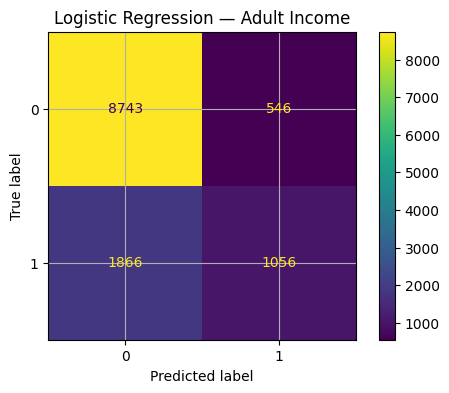

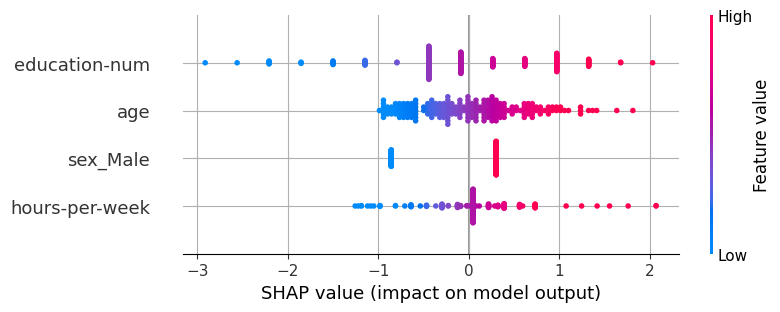

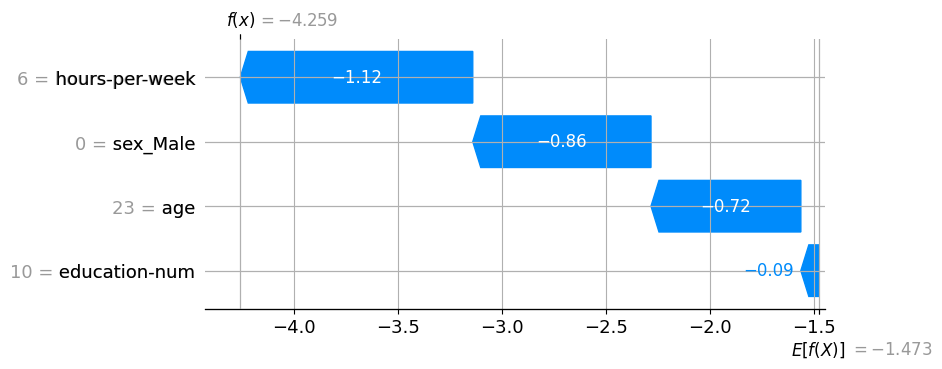


Top global features by mean |SHAP|:
 education-num     0.706748
age               0.487313
sex_Male          0.484843
hours-per-week    0.314427
dtype: float64

Tip: Red bars in beeswarm = higher feature values pushing prediction up towards >50K; blue = lower values pushing down.


In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import fetch_openml

plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True
np.random.seed(42)

# ==== Load & Prepare Data (Adult Income) ====
data = fetch_openml("adult", version=2, as_frame=True)
df = data.frame

# Keep a small, clean subset of columns
cols = ["age", "education-num", "hours-per-week", "sex", "class"]
df = df[cols].copy()
df["class"] = (df["class"] == ">50K").astype(int)

# One-hot encode categoricals; force numeric dtype to avoid SHAP/NumPy dtype hiccups
X = pd.get_dummies(df.drop(columns=["class"]), drop_first=True).astype("float64")
y = df["class"].astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# ==== Train Model ====
model = LogisticRegression(max_iter=200, n_jobs=None, solver="lbfgs")
model.fit(X_train, y_train)

# Basic metrics
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion matrix (quick visual)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(values_format="d")
plt.title("Logistic Regression — Adult Income")
plt.show()

# ==== SHAP Explanations ====
import shap


# Use the linear explainer (best match for LogisticRegression)
# Pass a DataFrame with float64 dtypes.
explainer = shap.Explainer(model, X_train, algorithm="linear")

# Use a manageable sample for plotting speed
X_sample = X_test.iloc[:200].astype("float64")
sv = explainer(X_sample)  # shap.Explanation

# --- Global importance ---
# Prefer modern beeswarm; if backend/env complains, fall back to bar.
try:
    shap.plots.beeswarm(sv, max_display=12)
    plt.show()
except Exception as e:
    print(f"[Info] beeswarm failed ({type(e).__name__}: {e}). Falling back to bar plot.")
    shap.plots.bar(sv, max_display=12)
    plt.show()

# --- Local explanation (pick a single row) ---
i = 5  # any index within X_sample
# Waterfall sometimes needs a base value present; shap.Explanation provides it.
try:
    shap.plots.waterfall(sv[i])
    plt.show()
except Exception as e:
    print(f"[Info] waterfall failed ({type(e).__name__}: {e}). Showing force plot instead.")
    # Force plot (matplotlib variant) as a robust fallback:
    shap.plots.force(sv[i], matplotlib=True)
    plt.show()

# ==== (Optional) Quick sanity notes printed ====
top_global = pd.Series(np.abs(sv.values).mean(axis=0), index=X_sample.columns).sort_values(ascending=False)[:8]
print("\nTop global features by mean |SHAP|:\n", top_global)
print("\nTip: Red bars in beeswarm = higher feature values pushing prediction up towards >50K; blue = lower values pushing down.")

### 🧭 1. Global summary plot (top chart)

This shows **which features matter most across the whole dataset** and how they affect predictions.

**Interpretation:**

* **x-axis = SHAP value** → how much each feature pushes the prediction toward or away from “>50K”.

  * Positive → increases chance of earning >50K.
  * Negative → decreases it.
* **Color = feature value** (red = high, blue = low).
* **Each dot = one individual**.

**From your plot:**

* **education-num** is the strongest positive feature — more education pushes predictions toward higher income.
* **hours-per-week**: higher hours (red) push income up; low hours (blue) push down.
* **sex_Male**: being male tends to push predictions up → this shows **model bias learned from data**.
* **age**: older individuals (red) are predicted more likely to have higher income.

🧩 **Key takeaway:** the model mostly bases its decisions on **education, age, work hours, and gender**, and gender has a measurable (and unwanted) effect.

---

### 💡 2. Local waterfall plot (bottom chart)

This explains **one single prediction** — why the model decided low or high income for that person.

**Reading it:**

* The bar length shows the strength of each feature’s impact.
* Blue bars → push prediction *down* (toward ≤50K).
* Red bars (if any) → push *up* (toward >50K).
* The number at the top (`f(x) = -4.259`) is the raw model output before converting to a probability — the lower it is, the more confident the model is about “low income.”

**In this example:**

* The person works few hours per week (strong negative impact).
* They are not male (`sex_Male = 0`), which also reduces the predicted income (gender bias again).
* Age and education slightly help, but not enough to flip the prediction.

🧠 **Meaning:** the model predicted “low income” mainly due to fewer work hours and gender, illustrating how bias manifests at the individual level.

---

### ✅ Summary

* **Global plot:** what generally drives predictions (education, hours, gender).
* **Local plot:** how those same features affected *one* person’s result.
* **Insight:** even a simple, accurate model can show **systematic bias**, here visible in the “sex_Male” feature’s positive contribution.



1) Core (10–15 min)

Task: Identify which feature has the largest average positive SHAP value for predicting >50K.

In [7]:
mean_abs = np.abs(sv.values).mean(axis=0)

# Show top 5 most influential features overall
pd.Series(mean_abs, index=X_sample.columns).sort_values(ascending=False).head()

education-num     0.706748
age               0.487313
sex_Male          0.484843
hours-per-week    0.314427
dtype: float64

2) Practice (10–15 min)

Task: Use permutation importance from scikit-learn to compare results.

In [8]:
from sklearn.inspection import permutation_importance
r = permutation_importance(model, X_test, y_test, n_repeats=5)
pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False).head()


education-num     0.060486
age               0.024371
sex_Male          0.017509
hours-per-week    0.014495
dtype: float64

3) Stretch (optional, 10–15 min)

Task: Install and run LIME for one test instance to see local explanation.

In [10]:
from lime.lime_tabular import LimeTabularExplainer

# Create the explainer
explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["<=50K", ">50K"],
    discretize_continuous=True,
    mode="classification"
)

# Explain one test instance
i = 0
exp = explainer.explain_instance(
    X_test.iloc[i].values,
    model.predict_proba,
    num_features=5
)

# --- Fix rendering issue ---
# Option 1: print as text
print(exp.as_list())

# Option 2: display as HTML manually (works in most environments)
from IPython.display import HTML, display
display(HTML(exp.as_html()))

c:\AI-Mastery\venv\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[('education-num <= 9.00', -0.2072807651373427), ('0.00 < sex_Male <= 1.00', 0.12508174024415886), ('hours-per-week <= 40.00', -0.11632174840955593), ('37.00 < age <= 48.00', 0.011651954766155352)]


Mini-Challenge (≤40 min)

Task: Produce a feature importance report summarizing the model’s decision logic.
Acceptance Criteria:
✅ Top 10 most influential features shown in a bar plot (use SHAP or permutation importance).
✅ Include at least one local example explanation (SHAP waterfall or LIME output).
✅ Write 3 bullet points interpreting which features drive income predictions most.

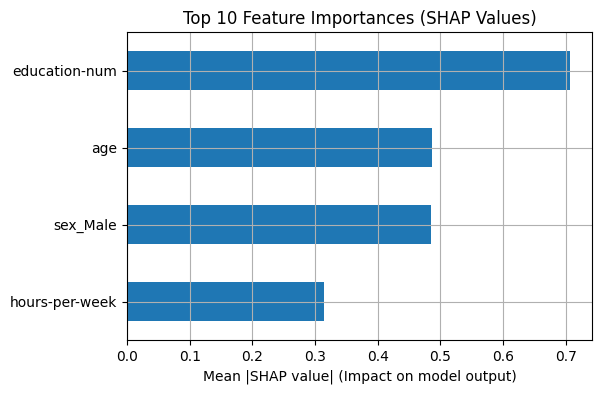

In [11]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# Compute mean absolute SHAP values for each feature
mean_abs = np.abs(sv.values).mean(axis=0)
feat_imp = pd.Series(mean_abs, index=X_sample.columns).sort_values(ascending=False)

# Plot top 10
feat_imp.head(10).plot(kind="barh", title="Top 10 Feature Importances (SHAP Values)")
plt.xlabel("Mean |SHAP value| (Impact on model output)")
plt.gca().invert_yaxis()
plt.show()


Education level (education-num) has the strongest positive effect — higher education consistently raises predicted income.

Work hours and age also play major roles: more hours and higher age both increase the likelihood of >50K.

Gender bias appears in sex_Male: being male slightly increases predicted income, reflecting societal imbalance learned from data.

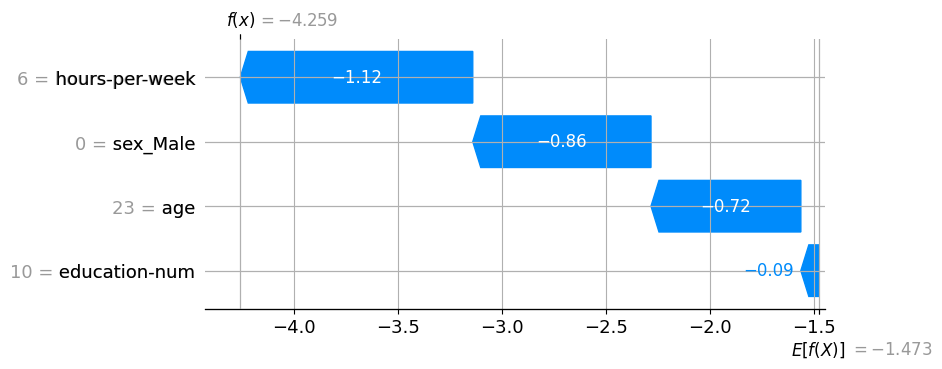

In [12]:
# Example SHAP local explanation (already computed)
i = 5
shap.plots.waterfall(sv[i])


Notes / Key Takeaways

SHAP gives consistent global and local explanations based on game theory.

LIME is simpler but powerful for quick “why” checks.

High feature impact doesn’t imply real-world causation.

Interpretability builds trust and accountability.

Combine methods: SHAP for global patterns, LIME for local cases.

Always interpret in context of fairness (from Day 1).

Reflection

Did any feature’s influence surprise you? Why might that be?

How could an explanation like this help communicate AI results to a policymaker?

-No not really.

-Visual explanations like SHAP or LIME make AI decisions transparent. A policymaker can see which factors drive predictions, spot unfair patterns (e.g., gender effects), and make informed choices about regulation, dataset fairness, or retraining needs. In short, these explanations turn complex model logic into evidence that supports accountable and ethical decision-making.